# 01 · Exploration et préparation des données

**Ce que fait ce notebook.** Il ouvre le jeu brut, en extrait la cible, mesure sa qualité sur six
dimensions, et décide ce qui entre dans le modèle, ainsi que ce qui en est **écarté, avec le motif écrit**.

Rien n'est modélisé ici. L'objectif est de pouvoir répondre à une seule question :
*est-ce que cette donnée mérite qu'on lui fasse confiance ?*

| Étape | Question posée |
|---|---|
| 1 · Le jeu brut | Que contient le fichier, exactement ? |
| 2 · ETL | Comment obtenir une cible exploitable ? |
| 3 · Qualité | Complétude, unicité, validité, cohérence, exactitude, actualité |
| 4 · Le piège `brand` | Un champ peut-il faire fuiter la cible ? |
| 5 · L'information disponible | Toutes les catégories sont-elles également décrites ? |
| 6 · La découpe | Comment garantir qu'aucune mesure ne triche ? |

In [1]:
import sys
from pathlib import Path

RACINE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RACINE))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

SURFACE, ENCRE, ENCRE_2 = "#fcfcfb", "#0b0b0b", "#52514e"
BLEU, BLEU_CLAIR, BLEU_FONCE, GRILLE = "#2a78d6", "#cde2fb", "#0d366b", "#e0dfdb"
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "font.size": 11,
        "text.color": ENCRE,
        "axes.labelcolor": ENCRE_2,
        "axes.edgecolor": GRILLE,
        "xtick.color": ENCRE_2,
        "ytick.color": ENCRE_2,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
print(f"racine du projet : {RACINE}")

racine du projet : /private/tmp/claude-501/-Users-trikwi-P15/f44c0be7-fdba-44bf-91a6-d59f2bf27089/scratchpad/build


## 1 · Jeu brut

On commence par regarder le fichier tel qu'il est livré, sans rien transformer.

In [2]:
CSV = RACINE / "data" / "flipkart_com-ecommerce_sample_1050.csv"
brut = pd.read_csv(CSV)

print(f"{brut.shape[0]} lignes × {brut.shape[1]} colonnes\n")
for c in brut.columns:
    print(f"  {c}")

1050 lignes × 15 colonnes

  uniq_id
  crawl_timestamp
  product_url
  product_name
  product_category_tree
  pid
  retail_price
  discounted_price
  image
  is_FK_Advantage_product
  description
  product_rating
  overall_rating
  brand
  product_specifications


Quinze colonnes, dont une large majorité est hors sujet pour la catégorisation : prix, note,
URL, horodatage de collecte. Trois seulement nous intéressent : l'identifiant, la description, et
l'arbre de catégories.

In [3]:
brut[["uniq_id", "product_name", "product_category_tree", "description"]].head(3)

,uniq_id,product_name,product_category_tree,description
0,55b85ea15a1536d46b7190ad6fff8ce7,Elegance Polyester Multicolor Abstract Eyelet ...,"[""Home Furnishing >> Curtains & Accessories >>...",Key Features of Elegance Polyester Multicolor ...
1,7b72c92c2f6c40268628ec5f14c6d590,Sathiyas Cotton Bath Towel,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",Specifications of Sathiyas Cotton Bath Towel (...
2,64d5d4a258243731dc7bbb1eef49ad74,Eurospa Cotton Terry Face Towel Set,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",Key Features of Eurospa Cotton Terry Face Towe...


## 2 · ETL · extraction de la cible

La catégorie n'est pas donnée telle quelle : elle est enfouie dans un **arbre** sérialisé en chaîne
de caractères. Regardons un exemple complet.

In [4]:
exemple = brut["product_category_tree"].iloc[0]
print(exemple)

["Home Furnishing >> Curtains & Accessories >> Curtains >> Elegance Polyester Multicolor Abstract Eyelet Do..."]


L'arbre descend jusqu'au produit lui-même, ce qui donnerait presque autant de catégories que
d'articles. **On ne retient que le premier niveau** : c'est le niveau auquel un acheteur navigue, et
celui auquel un vendeur se trompe.

La transformation est isolée dans `src/pipeline.py` : un seul endroit du code sait extraire la
catégorie, et le notebook comme le benchmark l'appellent.

In [5]:
from src.pipeline import LABEL_COL, TEXT_COL, load

df = load()
df.head(3)

,uniq_id,product_name,description,category,image
0,55b85ea15a1536d46b7190ad6fff8ce7,Elegance Polyester Multicolor Abstract Eyelet ...,Key Features of Elegance Polyester Multicolor ...,Home Furnishing,55b85ea15a1536d46b7190ad6fff8ce7.jpg
1,7b72c92c2f6c40268628ec5f14c6d590,Sathiyas Cotton Bath Towel,Specifications of Sathiyas Cotton Bath Towel (...,Baby Care,7b72c92c2f6c40268628ec5f14c6d590.jpg
2,64d5d4a258243731dc7bbb1eef49ad74,Eurospa Cotton Terry Face Towel Set,Key Features of Eurospa Cotton Terry Face Towe...,Baby Care,64d5d4a258243731dc7bbb1eef49ad74.jpg


In [6]:
effectifs = df[LABEL_COL].value_counts().sort_index()
print(effectifs.to_string())
print(f"\n{effectifs.nunique()} effectif(s) distinct(s) sur {len(effectifs)} catégories")

category
Baby Care                     150
Beauty and Personal Care      150
Computers                     150
Home Decor & Festive Needs    150
Home Furnishing               150
Kitchen & Dining              150
Watches                       150

1 effectif(s) distinct(s) sur 7 catégories


**Sept catégories, 150 articles chacune. L'équilibre est parfait.**

Ce n'est pas un détail de présentation, ça a deux conséquences directes :

- l'**exactitude** ne peut pas mentir ici : pas de classe majoritaire à imiter pour gonfler le score ;
- l'exactitude et la **F1 macro** vont donc presque coïncider. On gardera quand même la F1 macro,
  non pour la moyenne mais pour sa **lecture par classe**, seule capable de localiser l'erreur.

## 3 · Qualité · six dimensions, six tests

Le référentiel retenu est le corps de dimensions **DAMA**. Il est choisi pour une raison
opérationnelle : chacune de ses dimensions se traduit en test exécutable. Un référentiel purement
documentaire n'aurait pas cette propriété.

In [7]:
manquants = brut.isna().sum()
manquants = manquants[manquants > 0].sort_values(ascending=False)
print("COMPLÉTUDE — champs incomplets")
for c, n in manquants.items():
    print(f"  {c:24s} {n:4d}  ({n / len(brut):.0%})")
print(f"\n  description manquante : {brut['description'].isna().sum()}")

COMPLÉTUDE — champs incomplets
  brand                     338  (32%)
  retail_price                1  (0%)
  discounted_price            1  (0%)
  product_specifications      1  (0%)

  description manquante : 0


In [8]:
print("UNICITÉ")
print(f"  doublons d'identifiant : {brut['uniq_id'].duplicated().sum()}")
print(f"  doublons de description : {brut['description'].duplicated().sum()}")

print("\nCOHÉRENCE")
print(f"  lignes avec une image référencée : {brut['image'].notna().sum()} / {len(brut)}")

UNICITÉ
  doublons d'identifiant : 0
  doublons de description : 0

COHÉRENCE
  lignes avec une image référencée : 1050 / 1050


| Dimension | Test | Résultat | Verdict |
|---|---|---|---|
| Complétude | descriptions manquantes | 0 | ✅ |
| Complétude | autres champs | `brand` 32 %, trois champs à 1 | ⚠️ |
| Unicité | doublons d'identifiant et de description | 0 et 0 | ✅ |
| Validité | catégories hors nomenclature | 7 catégories, 150 chacune | ✅ |
| Cohérence | appariement description ↔ image ↔ identifiant | 1 050 / 1 050 | ✅ |
| Exactitude | la catégorie décrit-elle vraiment l'article ? | **non vérifiable** | ⚠️ |
| Actualité | fraîcheur du corpus | collecte 2016 | ⚠️ |

Les deux avertissements du bas ne se testent pas, et ils comptent plus que les autres.

**L'exactitude est non vérifiable** parce que la vérité terrain est *déclarée par les vendeurs* : les
mêmes dont on cherche à corriger les erreurs. C'est une circularité qu'il faut énoncer : elle place
une **borne haute** sur toute performance mesurée. Un modèle qui atteindrait 100 % aurait simplement
appris à reproduire les erreurs de saisie.

## 4 · Champ `brand`

Le champ `brand` manque sur un tiers des articles. La question naturelle est : peut-on l'utiliser
quand il est présent ? Regardons **comment** ces valeurs manquantes se répartissent.

In [9]:
absence = (
    brut.assign(sans_marque=brut["brand"].isna(), categorie=df[LABEL_COL])
    .groupby("categorie")["sans_marque"]
    .agg(["sum", "mean"])
    .sort_values("sum", ascending=False)
)
absence.columns = ["articles sans marque", "part"]
absence["part"] = (absence["part"] * 100).round(0).astype(int).astype(str) + " %"
absence

,articles sans marque,part
categorie,,
Watches,140,93 %
Beauty and Personal Care,109,73 %
Kitchen & Dining,71,47 %
Baby Care,16,11 %
Home Decor & Festive Needs,2,1 %
Computers,0,0 %
Home Furnishing,0,0 %


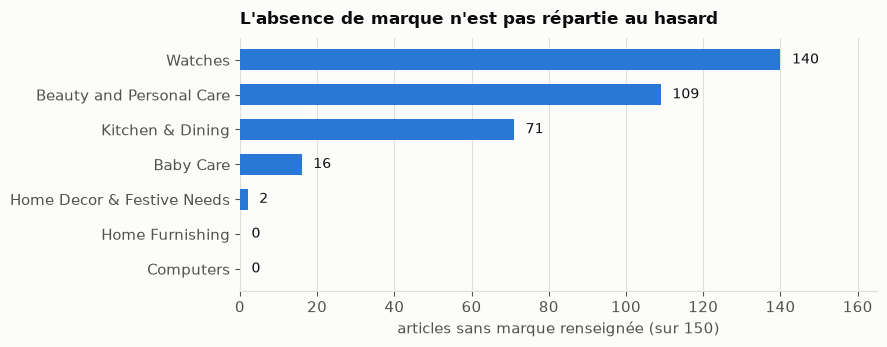

In [10]:
fig, ax = plt.subplots(figsize=(9, 3.6))
v = absence["articles sans marque"].sort_values()
ax.barh(v.index, v.values, color=BLEU, height=0.6, zorder=3)
for i, n in enumerate(v.values):
    ax.text(n + 3, i, str(n), va="center", fontsize=10, color=ENCRE)
ax.set_xlim(0, 165)
ax.set_xlabel("articles sans marque renseignée (sur 150)")
ax.grid(axis="x", color=GRILLE, lw=0.8, zorder=0)
ax.set_title(
    "L'absence de marque n'est pas répartie au hasard",
    fontsize=12,
    fontweight="bold",
    loc="left",
    pad=10,
)
plt.tight_layout()
plt.show()

**Voilà le piège.** 140 montres sur 150 n'ont pas de marque renseignée, contre **0 sur 150** en
informatique et en ameublement. L'absence de la marque prédit donc la catégorie mieux que la plupart
des mots de la description.

Utiliser `brand`, ou même un simple indicateur « marque renseignée oui/non », ferait entrer dans le
modèle une information qui n'a rien à voir avec la nature du produit : elle refléterait les habitudes
de saisie des vendeurs de cette collecte-là. Le score monterait, la généralisation s'effondrerait.

> **Décision : le champ `brand` est écarté du modèle, et le motif est écrit.** C'est le premier
> arbitrage du projet, et il coûte du score volontairement.

## 5 · Information disponible

Les classes sont équilibrées en **nombre**. Le sont-elles en **information** ?

In [11]:
longueurs = df[TEXT_COL].str.split().str.len()
print("longueur des descriptions, en mots")
print(
    f"  min {longueurs.min()} · q25 {longueurs.quantile(0.25):.0f} · médiane {longueurs.median():.0f}"
    f" · q75 {longueurs.quantile(0.75):.0f} · max {longueurs.max()} · moyenne {longueurs.mean():.1f}"
)

par_cat = df.assign(n=longueurs).groupby(LABEL_COL)["n"].agg(["median", "min", "max"])
par_cat.sort_values("median")

longueur des descriptions, en mots
  min 13 · q25 30 · médiane 44 · q75 94 · max 587 · moyenne 76.2


,median,min,max
category,,,
Home Furnishing,24.0,18,395
Beauty and Personal Care,34.0,19,587
Computers,37.0,21,570
Home Decor & Festive Needs,45.0,19,404
Watches,46.0,26,272
Baby Care,57.5,13,419
Kitchen & Dining,88.0,16,364


**Non.** La description médiane va de 24 mots pour *Home Furnishing* à 88 pour *Kitchen &
Dining*, soit un facteur 3,7. Une catégorie décrite en trois mots offre beaucoup moins de prise qu'une
autre détaillée sur cinq lignes.

C'est une hypothèse à retenir pour la suite : **les catégories les moins décrites devraient être les
moins bien classées.** On le vérifiera au notebook 03.

## 6 · Découpe · garantie d'indépendance

Toutes les mesures du projet reposent sur une seule partition, définie **une fois** dans
`src/pipeline.py` : 70 / 15 / 15, stratifiée, à graine fixe.

Un seul endroit découpe. Le benchmark, les notebooks et la démonstration l'appellent tous. C'est ce qui
garantit que les chiffres se comparent entre eux.

In [12]:
from src.pipeline import split

train, val, test = split(df)
print(f"entraînement {len(train)} · validation {len(val)} · test {len(test)}")

a, b, c = (set(p["uniq_id"]) for p in (train, val, test))
print(f"\nintersections : train∩val {len(a & b)} · train∩test {len(a & c)} · val∩test {len(b & c)}")
print(f"union = jeu complet : {len(a | b | c) == len(df)}")

print("\nrépartition des catégories dans chaque pli")
pd.DataFrame(
    {
        "entraînement": train[LABEL_COL].value_counts(normalize=True),
        "validation": val[LABEL_COL].value_counts(normalize=True),
        "test": test[LABEL_COL].value_counts(normalize=True),
    }
).round(3)

entraînement 735 · validation 157 · test 158

intersections : train∩val 0 · train∩test 0 · val∩test 0
union = jeu complet : True

répartition des catégories dans chaque pli


,entraînement,validation,test
category,,,
Baby Care,0.143,0.146,0.139
Beauty and Personal Care,0.143,0.146,0.139
Computers,0.143,0.140,0.146
Home Decor & Festive Needs,0.143,0.140,0.146
Home Furnishing,0.143,0.140,0.146
Kitchen & Dining,0.143,0.146,0.139
Watches,0.143,0.140,0.146


Trois intersections vides, une union complète, et les sept catégories présentes en proportions
quasi identiques dans chaque pli. Ces quatre propriétés sont **testées automatiquement** dans
`tests/test_pipeline.py`, notamment la disjonction, qui est le test anti-fuite du projet.

## Sorties du carnet

| | |
|---|---|
| **Cible** | catégorie de niveau 1, 7 classes, 150 articles chacune |
| **Entrée retenue** | la description textuelle, et la photographie (notebook 04) |
| **Écarté** | `brand` : son absence prédit la cible |
| **Limite assumée** | vérité terrain déclarative : borne haute sur la performance |
| **Partition** | 735 / 157 / 158, stratifiée, graine 42, disjonction testée |

→ Notebook suivant : **02 · Visualisation**, pour voir si les catégories se séparent.